# Logistic Regression From Scratch

Logistic Regression is a supervised machine learning algorithm used for binary
classification.

It predicts the probability that an observation belongs to a particular class.

### Learning Objectives

- Understand the sigmoid function
- Implement Logistic Regression from scratch
- Train using Gradient Descent
- Evaluate classification performance
- Compare the implementation with Scikit-Learn

## 1. Mathematical Foundation

Logistic Regression first calculates a linear combination:

$$
z = Xw + b
$$

The sigmoid function converts this value into a probability:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The binary cross-entropy loss function is:

$$
J = -\frac{1}{n}\sum_{i=1}^{n}
[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)]
$$

The predicted probability is converted into a class using a threshold of 0.5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression

## 2. Generate Dataset

A synthetic binary classification dataset will be generated with two features.

Feature scaling will be applied using statistics from the training data only.

In [2]:
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300, 2)
y shape: (300,)


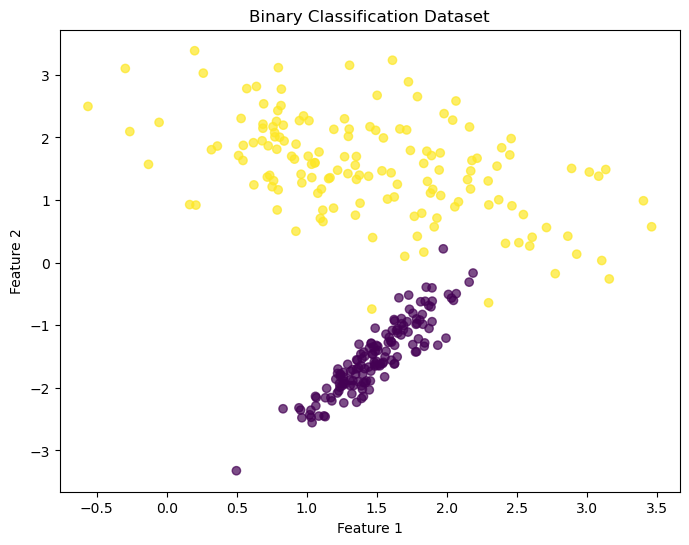

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")

plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])

Training samples: 240
Testing samples: 60


## 3. Implement Logistic Regression From Scratch

The model will include:

- Sigmoid activation
- Binary cross-entropy loss
- Gradient Descent
- Probability predictions
- Class predictions
- Loss tracking

In [5]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.1, iterations=2000):
        self.learning_rate = learning_rate
        self.iterations = iterations

        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        y = y.flatten()

        for i in range(self.iterations):

            # Linear combination
            linear_output = np.dot(X, self.weights) + self.bias

            # Predicted probabilities
            probabilities = self.sigmoid(linear_output)

            # Gradients
            error = probabilities - y

            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Binary cross-entropy loss
            probabilities_clipped = np.clip(
                probabilities,
                1e-15,
                1 - 1e-15
            )

            loss = -np.mean(
                y * np.log(probabilities_clipped)
                + (1 - y) * np.log(1 - probabilities_clipped)
            )

            self.loss_history.append(loss)

        return self

    def predict_proba(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        return self.sigmoid(linear_output)

    def predict(self, X, threshold=0.5):

        probabilities = self.predict_proba(X)

        return (probabilities >= threshold).astype(int)